In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ecg-data/mitbih_test.csv
/kaggle/input/ecg-data/mitbih_train.csv
/kaggle/input/ecg-model/tensorflow2/default/1/ecg_attention_extractor.h5


In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Layer
from sklearn.model_selection import train_test_split


2026-01-14 05:12:20.885656: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768367541.070652      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768367541.124281      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768367541.567595      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768367541.567646      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768367541.567649      23 computation_placer.cc:177] computation placer alr

In [3]:
df = pd.read_csv("/kaggle/input/ecg-data/mitbih_train.csv", header=None)

X = df.iloc[:, :-1].values   # (N, 187)
y = df.iloc[:, -1].values


In [4]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [5]:
def moving_average(signal, window=5):
    return np.convolve(signal, np.ones(window) / window, mode="same")

def create_ts_channels(signal):
    original = signal
    smooth = moving_average(signal)
    derivative = np.gradient(signal)

    def norm(x):
        return (x - np.mean(x)) / (np.std(x) + 1e-8)

    return np.stack([
        norm(original),
        norm(smooth),
        norm(derivative)
    ], axis=1)

X_val_ts = np.array([create_ts_channels(x) for x in X_val])
print(X_val_ts.shape)   # (samples, 187, 3)


(17511, 187, 3)


In [6]:
import tensorflow as tf
from tensorflow.keras.layers import Layer

class TemporalAttention(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(
            name="att_weight",
            shape=(input_shape[-1], 1),
            initializer="normal"
        )
        self.b = self.add_weight(
            name="att_bias",
            shape=(input_shape[1], 1),
            initializer="zeros"
        )

    def call(self, x):
        e = tf.tanh(tf.matmul(x, self.W) + self.b)
        a = tf.nn.softmax(e, axis=1)
        output = tf.reduce_sum(x * a, axis=1)
        return output, a

    def get_config(self):
        config = super().get_config()
        return config


In [7]:
model = load_model(
    "/kaggle/input/ecg-model/tensorflow2/default/1/ecg_attention_extractor.h5",  # adjust path if needed
    custom_objects={"TemporalAttention": TemporalAttention}
)

model.trainable = False
model.summary()



I0000 00:00:1768367564.984381      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 187, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 187, 128)       │        34,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 187, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 187, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 187, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_attention              │ [(None, 128), (None,   │           315 │
│ (TemporalAttention)             │ 187, 1)]               │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,947 (523.23 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 133,947 (523.23 KB)

In [8]:
idx = 10
x_sample = tf.convert_to_tensor(
    X_val_ts[idx:idx+1], dtype=tf.float32
)


## Attention Visualization (Timestamps emphasized)

In [9]:
from tensorflow.keras.models import Model

# Get the attention layer by name
att_layer = model.get_layer('temporal_attention')

# Create a new model from input to the attention layer
att_model = Model(inputs=model.input, outputs=att_layer.output)

# Get both outputs (context and attention)
context_vec, attention = att_model(x_sample, training=False)
attention = attention.numpy().squeeze()




I0000 00:00:1768367566.720072      63 cuda_dnn.cc:529] Loaded cuDNN version 91002


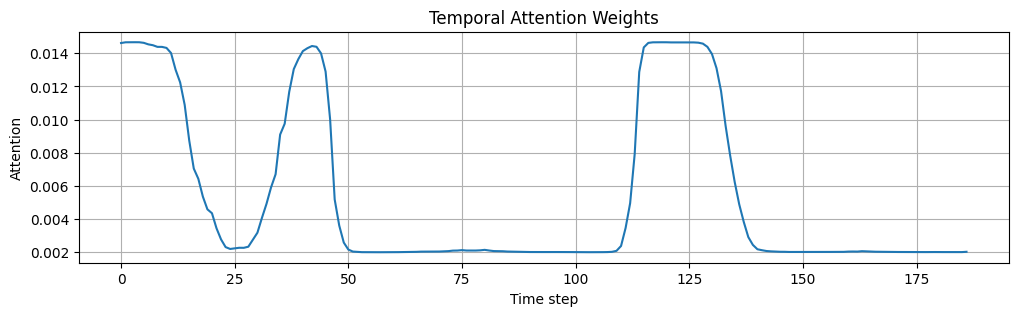

In [10]:
plt.figure(figsize=(12,3))
plt.plot(attention)
plt.title("Temporal Attention Weights")
plt.xlabel("Time step")
plt.ylabel("Attention")
plt.grid()
plt.show()

## SALIENCY OF ATTENTION

In [11]:
with tf.GradientTape() as tape:
    tape.watch(x_sample)
    _, attention = att_model(x_sample, training=False)  
    attention_sum = tf.reduce_sum(attention)

grads = tape.gradient(attention_sum, x_sample)[0]   # (187, 3)

saliency = tf.abs(grads)
saliency_time = tf.reduce_mean(saliency, axis=1).numpy()
saliency_norm = saliency_time / (saliency_time.max() + 1e-8)




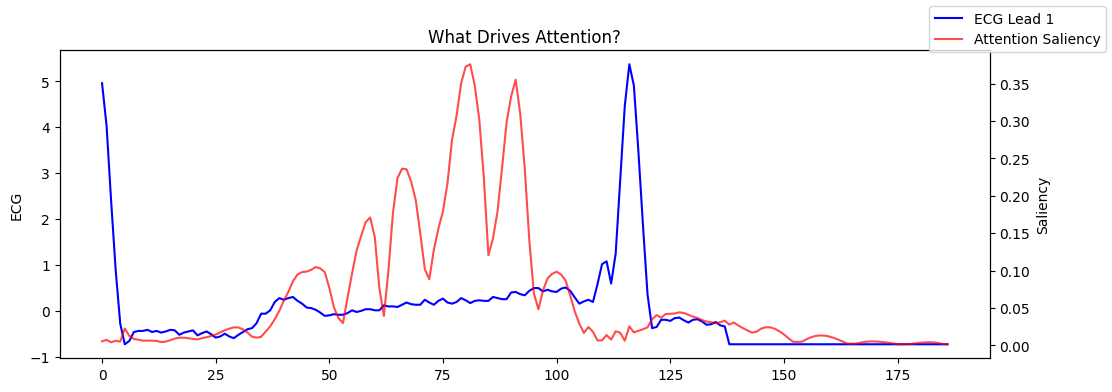

In [12]:
time = np.arange(187)
fig, ax1 = plt.subplots(figsize=(12,4))

ax1.plot(time, x_sample[0,:,0], color="blue", label="ECG Lead 1")
ax1.set_ylabel("ECG")

ax2 = ax1.twinx()
ax2.plot(time, saliency_norm, color="red", alpha=0.7, label="Attention Saliency")
ax2.set_ylabel("Saliency")

fig.legend(loc="upper right")
plt.title("What Drives Attention?")
plt.show()

## Attention Stability (Does attention change under noise?)

In [13]:
noise_std = 0.05
x_noisy = x_sample + tf.random.normal(x_sample.shape, stddev=noise_std)

_, att_clean = att_model(x_sample, training=False)   # ✅ use att_model
_, att_noisy = att_model(x_noisy, training=False)

att_clean = att_clean.numpy().squeeze()
att_noisy = att_noisy.numpy().squeeze()




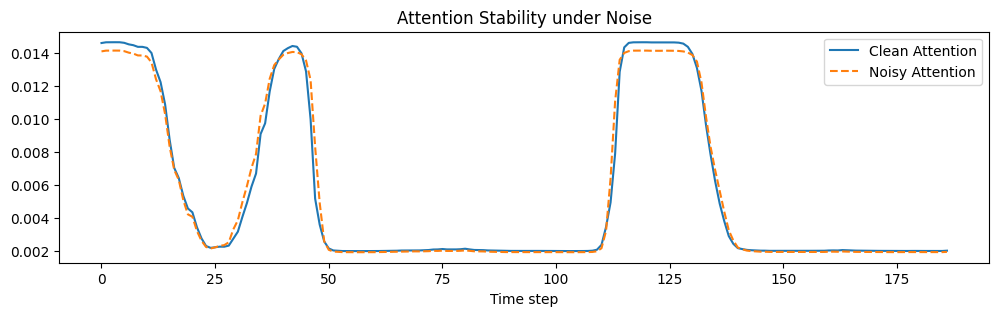

In [14]:
plt.figure(figsize=(12,3))
plt.plot(att_clean, label="Clean Attention")
plt.plot(att_noisy, label="Noisy Attention", linestyle="--")
plt.legend()
plt.title("Attention Stability under Noise")
plt.xlabel("Time step")
plt.show()


## Integrated Gradients on Attention

In [15]:
baseline = tf.zeros_like(x_sample)
steps = 50

alphas = tf.linspace(0.0, 1.0, steps)
ig = tf.zeros_like(x_sample)

for alpha in alphas:
    x_interp = baseline + alpha * (x_sample - baseline)

    with tf.GradientTape() as tape:
        tape.watch(x_interp)
        _, attention = att_model(x_interp, training=False)  # ✅ use att_model
        att_sum = tf.reduce_sum(attention)

    grads = tape.gradient(att_sum, x_interp)
    ig += grads

ig = ig / steps * (x_sample - baseline)
ig_time = tf.reduce_mean(tf.abs(ig[0]), axis=1).numpy()
ig_norm = ig_time / (ig_time.max() + 1e-8)



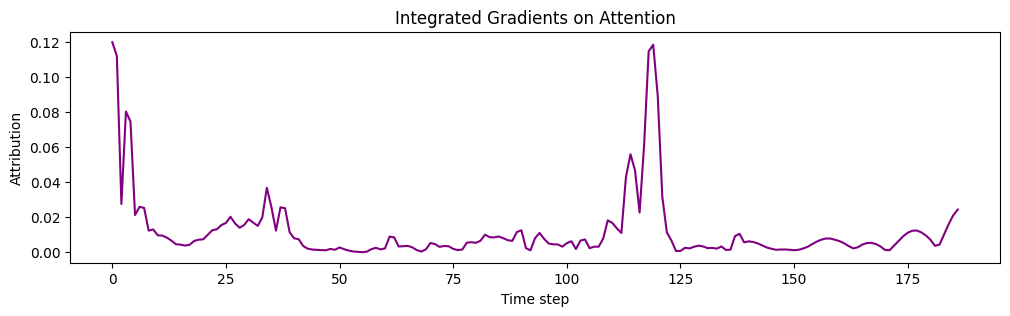

In [16]:
plt.figure(figsize=(12,3))
plt.plot(ig_norm, color="purple")
plt.title("Integrated Gradients on Attention")
plt.xlabel("Time step")
plt.ylabel("Attribution")
plt.show()
